新的图1

In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3

df_moves = pd.read_parquet(r'..\df_moves6.parquet')

In [2]:
df_moves.shape

(88912034, 40)

In [3]:
num_unique_uids = df_moves['uid'].nunique()
print(f"uid列共有 {num_unique_uids} 个不同的值")

uid列共有 1012241 个不同的值


In [4]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

In [5]:
df_moves[['uid', 'Move_Idx', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5', 'Δ']].head()

,uid,Move_Idx,Color,E,E1,E2,E3,E4,E5,Δ
0,34,1,White,33.0,36.0,34,31,25,16,6.0
1,34,2,Black,36.0,33.0,34,34,42,48,4.0
2,34,3,White,30.0,36.0,33,27,25,20,7.0
3,34,4,Black,44.0,30.0,63,66,78,79,38.0
4,34,5,White,32.0,44.0,35,26,21,21,15.0


### 图1的第一大部分图片    一个board， 画了三个随便选一个就行    
#### uid=34 move_index = 7, 31, 35    (走子计数从1开始)

In [6]:
steps_str = 'e2e4,c7c6,d2d4,d7d5,e4e5,c8f5,g1f3,e7e6,f1e2,g8e7,c2c3,f5g6,a2a4,e7f5,e1g1,f8e7,a4a5,a7a6,b2b4,e8g8,b1a3,b8d7,a3c2,f7f6,g2g4,f5h6,e5f6,f8f6,g4g5,g6c2,d1c2,f6g6,h2h4,d7f6,f3e5,h6f5,e5g6,h7g6,g5f6,e7f6,e2g4,g8f7,c1f4,g6g5,h4g5,f6g5,c2d2,g5f6,g4f5,e6f5,g1g2,g7g5,f4e5,d8d7,f1h1,f7g6,e5f6,f5f4,d2d3,g6f6,h1h6,f6g7,d3h7'
moves = steps_str.split(',')
board = chess.Board()
target_indices = [7, 31, 35]
fens = {}
for i in range(len(moves)+1):
    move_idx = i+1
    if move_idx in target_indices:
        fens[move_idx] = board.fen()
    if i < len(moves):
        board.push_uci(moves[i])
for idx, fen in fens.items():
    print(f'Move_Idx {idx}----FEN: {fen}')

Move_Idx 7----FEN: rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4
Move_Idx 31----FEN: r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16
Move_Idx 35----FEN: r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18


In [7]:
class SimpleStockfishEngine:
    """保留了抓取 pv 走法的能力"""
    def __init__(self, engine_path, threads=1, multi_pv=5):
        self.engine_path = Path(engine_path)
        if not self.engine_path.exists():
            raise FileNotFoundError(f"引擎路径不存在: {engine_path}")
        
        self.process = subprocess.Popen(
            str(self.engine_path),
            universal_newlines=True,
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            bufsize=1
        )
        self._send_command("uci")
        self._wait_for("uciok")
        self._send_command(f"setoption name Threads value {threads}")
        self._send_command(f"setoption name MultiPV value {multi_pv}")
        self._send_command("isready")
        self._wait_for("readyok")
    
    def _send_command(self, command):
        self.process.stdin.write(f"{command}\n")
        self.process.stdin.flush()
    
    def _wait_for(self, text, timeout=5.0):
        start_time = time.time()
        while time.time() - start_time < timeout:
            line = self.process.stdout.readline().strip()
            if text in line:
                return line
        raise TimeoutError(f"等待'{text}'超时")
    
    def analyse(self, board, depth=18):
        fen = board.fen()
        self._send_command(f"position fen {fen}")
        self._send_command(f"go depth {depth}")
        pv_info = {} 
        
        while True:
            line = self.process.stdout.readline().strip()
            if "bestmove" in line:
                break
            if "score" in line and "multipv" in line:
                try:
                    parts = line.split()
                    mpv_id = int(parts[parts.index("multipv") + 1])
                    score_type = parts[parts.index("score") + 1]
                    score_val = int(parts[parts.index("score") + 2])
                
                    if score_type == "cp":
                        score_obj = chess.engine.Cp(score_val)
                    elif score_type == "mate":
                        score_obj = chess.engine.Mate(score_val)
                    else:
                        score_obj = chess.engine.Cp(0)
                        
                    move_name = "Unknown"
                    if "pv" in parts:
                        move_name = parts[parts.index("pv") + 1] 
                
                    pv_info[mpv_id] = {"score": score_obj, "move": move_name}
                except (ValueError, IndexError):
                    pass
        return pv_info
    
    def quit(self):
        self._send_command("quit")
        self.process.terminate()

def get_raw_cp_like_dataframe(score_obj, board, mate_cap=10000):
    """
    复刻原代码中 ComplexityAnalyzer.score_to_cp 和视角转换的逻辑。
    """
    if score_obj is None: 
        return None
        
    if isinstance(score_obj, chess.engine.Mate):
        mate_steps = score_obj.mate()
        if mate_steps > 0:
            val = mate_cap - mate_steps
        else:
            val = -mate_cap - mate_steps
    else:
        val = score_obj.score()
        
    # 视角转换：对齐你 DataFrame 里的白方视角要求
    if board.turn == chess.WHITE:
        return val
    else:
        return -val

# ================= 运行测试区 =================
if __name__ == "__main__":
    # 你的引擎路径
    ENGINE_PATH = r"C:\Users\Administrator\Desktop\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe"
    
    # 你想要验证的 FEN
    fens_to_test = {
        "Move_Idx 7 (高模糊度/图c)": "rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4",
        "Move_Idx 31 (低模糊度/图b)": "r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16",
        "Move_Idx 35 (图a)": "r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18"
    }
    
    engine = SimpleStockfishEngine(ENGINE_PATH, threads=1, multi_pv=5)
    
    try:
        for name, fen_str in fens_to_test.items():
            print(f"\n[{name}]")
            print(f"原局面 FEN: {fen_str}")
            
            board = chess.Board(fen_str)
            results = engine.analyse(board, depth=18) 
            
            print(f"{'Rank':<4} | {'Move':<6} | {'DF Score':<8} | {'走子后的新 FEN'}")
            print("-" * 80)
            
            for i in range(1, 6):
                if i in results:
                    info = results[i]
                    move_str = info["move"]
                    
                    # 强行使用你 DataFrame 里的逻辑去算分
                    raw_score = get_raw_cp_like_dataframe(info["score"], board)
                    
                    # 模拟走子并拿新 FEN
                    board_copy = board.copy()
                    try:
                        board_copy.push(chess.Move.from_uci(move_str))
                        new_fen = board_copy.fen()
                    except:
                        new_fen = "Error"
                    
                    print(f"Top{i:<2} | {move_str:<6} | {str(raw_score):<8} | {new_fen}")
            
    finally:
        engine.quit()


[Move_Idx 7 (高模糊度/图c)]
原局面 FEN: rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP2PPP/RNBQKBNR w KQkq - 1 4
Rank | Move   | DF Score | 走子后的新 FEN
--------------------------------------------------------------------------------
Top1  | f1e2   | 43       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPP1BPPP/RNBQK1NR b KQkq - 2 4
Top2  | g1f3   | 40       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/5N2/PPP2PPP/RNBQKB1R b KQkq - 2 4
Top3  | h2h4   | 34       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P3P/8/PPP2PP1/RNBQKBNR b KQkq - 0 4
Top4  | b1d2   | 27       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/8/PPPN1PPP/R1BQKBNR b KQkq - 2 4
Top5  | c2c3   | 26       | rn1qkbnr/pp2pppp/2p5/3pPb2/3P4/2P5/PP3PPP/RNBQKBNR b KQkq - 0 4

[Move_Idx 31 (低模糊度/图b)]
原局面 FEN: r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2b1BP1P/R1BQ1RK1 w - - 0 16
Rank | Move   | DF Score | 走子后的新 FEN
--------------------------------------------------------------------------------
Top1  | d1c2   | 115      | r2q2k1/1p1nb1pp/p1p1pr1n/P2p2P1/1P1P4/2P2N2/2Q1BP1P/R1B2RK1 b - - 0 16
To

basic info

In [8]:
def show_board_with_scores(fen, candidate_moves, 
                           b_name="Black: ", b_elo="????", b_clock="--:--",
                           w_name="White", w_elo="????", w_clock="--:--",
                           board_size=400, save_path=None):
    board = chess.Board(fen)
    
    colors = ["#228B22", "#1E90FF", "#8A2BE2", "#FF8C00", "#DC143C"]
    arrows = []
    
    # 开始构建右侧的 Legend HTML
    legend_html = "<div style='display: flex; flex-direction: column; justify-content: space-between; margin-left: 25px; font-family: -apple-system, BlinkMacSystemFont, \"Segoe UI\", Roboto, Arial, sans-serif; height: {}px;'>".format(board_size)
    
    # ===== 1. 顶部：黑方选手信息 =====
    black_info_html = f"""
    <div style='margin-bottom: 15px;'>
        <div style='font-size: 16px; font-weight: bold; color: #333;'>
            Black: {b_name} &nbsp;&nbsp;&nbsp; <span style='font-weight: normal; color: #666;'>ELO: {b_elo}</span>
        </div>
        <div style='font-size: 14px; font-family: monospace; color: #444; margin-top: 2px;'>
            Clock: {b_clock}
        </div>
    </div>
    """
    
    # ===== 2. 中间：Stockfish 评估内容 =====
    eval_content_html = "<div>"
    eval_content_html += "<h4 style='margin: 0 0 5px 0; font-weight: bold;'>Stockfish Evaluation</h4>"
    eval_content_html += f"<div style='margin-bottom: 12px; font-size: 13px; color: #555; border-bottom: 1.5px solid #ccc; padding-bottom: 5px;'>Top {len(candidate_moves)} Moves (Unit: cp)</div>"
    
    for i, (uci, score) in enumerate(candidate_moves):
        color = colors[i % len(colors)]
        move = chess.Move.from_uci(uci)
        arrows.append(chess.svg.Arrow(move.from_square, move.to_square, color=color))
        
        eval_content_html += f"<div style='display: flex; align-items: center; margin-bottom: 8px;'>"
        eval_content_html += f"<div style='width: 14px; height: 14px; background-color: {color}; margin-right: 10px; border-radius: 2px;'></div>"
        eval_content_html += f"<span style='font-size: 14px;'>Rank {i+1} (<b>{uci}</b>): <span style='font-family: monospace;'>{score:+} cp</span></span>"
        eval_content_html += "</div>"
    
    # Delta 计算
    if len(candidate_moves) > 1:
        sign = 1 if board.turn == chess.WHITE else -1
        weights = [0.48, 0.24, 0.16, 0.12]
        E1 = candidate_moves[0][1]
        numerator, denominator = 0.0, 0.0
        for i in range(1, len(candidate_moves)):
            if i-1 < len(weights):
                Ek = candidate_moves[i][1]
                w_k = weights[i - 1]
                numerator += w_k * (E1 - Ek) * sign
                denominator += w_k
        if denominator > 0:
            delta_val = numerator / denominator
            eval_content_html += f"<div style='margin-top: 10px; padding-top: 10px; border-top: 1px dashed #aaa; font-size: 14px;'>"
            eval_content_html += f"<b>Δ_top5:</b> {delta_val:.2f} cp"
            eval_content_html += "</div>"
    eval_content_html += "</div>"
    
    # ===== 3. 底部：白方选手信息 =====
    white_info_html = f"""
    <div style='margin-top: 15px;'>
        <div style='font-size: 14px; font-family: monospace; color: #444; margin-bottom: 2px;'>
            Clock: {w_clock}
        </div>
        <div style='font-size: 16px; font-weight: bold; color: #333;'>
            White: {w_name} &nbsp;&nbsp;&nbsp; <span style='font-weight: normal; color: #666;'>ELO: {w_elo}</span>
        </div>
    </div>
    """
    
    # 组合所有部分
    legend_html += black_info_html + eval_content_html + white_info_html
    legend_html += "</div>"
    
    # ===== 生成 SVG =====
    board_svg = chess.svg.board(board=board, arrows=arrows, size=board_size, coordinates=True)
    final_html = f"<div style='display: flex; flex-direction: row; align-items: flex-start;'>{board_svg}{legend_html}</div>"
    
    # 显示
    display(HTML(final_html))
    
    # 保存
    if save_path:
        with open(save_path.replace(".png", ".html"), "w", encoding="utf-8") as f:
            f.write(final_html)
        with open(save_path.replace(".png", ".svg"), "w", encoding="utf-8") as f:
            f.write(board_svg)
print(">>> 渲染 Move_Idx 35 (图a) <<<")

>>> 渲染 Move_Idx 35 (图a) <<<


In [9]:
#：图 (a) 素材 (Move_Idx 35)  此时局面是第34步走完后的局面，实际采取动作是蓝色  轮到白方走了  
# 剩余时间 白方：'0:02:26.5'   黑方： '0:02:02.9'
# whiteelo: 2802     blackelo:2463
test_fen_a = "r2q2k1/1p2b1pp/p1p1pnrn/P2p2P1/1P1P3P/2P2N2/2Q1BP2/R1B2RK1 w - - 1 18"
test_moves_a = [
    ("e2d3", 359), 
    ("f3e5", 351), 
    ("f1e1", 344), 
    ("g1g2", 271), 
    ("g1h1", 266)
]
# 剩余时间 白方：'0:02:26.5'   黑方： '0:02:02.9'
show_board_with_scores(test_fen_a, test_moves_a,
                           b_name="Petar Ratkovic", b_elo="2463", b_clock="0:02:02.9",
                           w_name="Dennis Wagner", w_elo="2802", w_clock="0:02:26.5",
                           board_size=400, save_path=None)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16160\4188166233.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_moves.groupby('Progress_Bin')['Δ'].mean().reset_index()


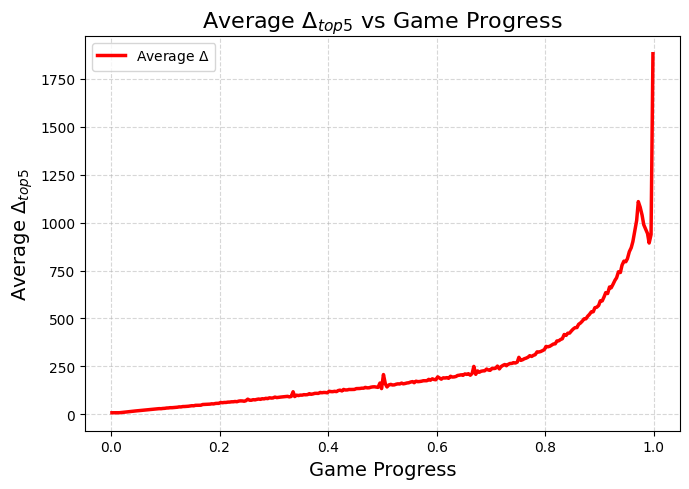

In [10]:
plt.figure(figsize=(7, 5))
df_moves['Progress_Bin'] = pd.cut(df_moves['Progress'], bins=300)
df_mean = df_moves.groupby('Progress_Bin')['Δ'].mean().reset_index()
df_mean['Progress'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

# 画均值线
plt.plot(df_mean['Progress'], df_mean['Δ'], color='red', linewidth=2.5, label=r'Average $\Delta$')
plt.title(r'Average $\Delta_{top5}$ vs Game Progress', fontsize=16)
plt.xlabel('Game Progress', fontsize=14)
plt.ylabel(r'Average $\Delta_{top5}$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
del df_mean
gc.collect()

3493

#Mask来剔除所有 Is_Forced == 1 的强制走子)    其实和前面的图一样
musk = df_moves[df_moves['Is_Forced'] != 1]     
可以参考figure1_0.ipynb    可以看到仅去除强制走子后图长啥样

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16160\2463443652.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16160\2463443652.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = musk.groupby('Progress_Bin')[['Δ','Δi']].mean().reset_index()


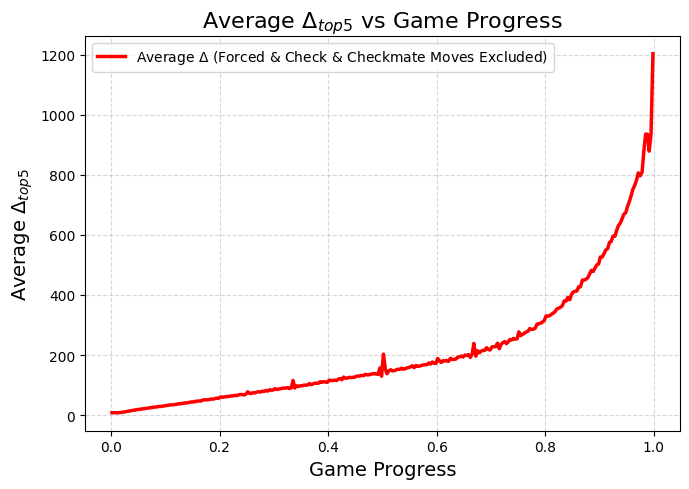

5176

In [12]:
# 剔除强制走子 check和checkmate
musk = df_moves[(df_moves['Is_Forced'] != 1) & (df_moves['Is_check'] != 1) & (df_moves['Is_checkmate'] != 1)]

plt.figure(figsize=(7, 5))
musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
df_mean = musk.groupby('Progress_Bin')[['Δ','Δi']].mean().reset_index()

df_mean['Progress'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

plt.plot(df_mean['Progress'], df_mean['Δ'], color='red', linewidth=2.5, label=r'Average $\Delta$ (Forced & Check & Checkmate Moves Excluded)')
# plt.plot(df_mean['Progress'], df_mean['Δi'], color='blue', linewidth=2.5, label=r'Average $\Delta_i$ (Forced Moves Excluded)')

plt.title(r'Average $\Delta_{top5}$ vs Game Progress', fontsize=16)
plt.xlabel('Game Progress', fontsize=14)
plt.ylabel(r'Average $\Delta_{top5}$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5) 
plt.legend()
plt.tight_layout()
plt.show()

del musk
gc.collect()

去除check和checkmate之后接近结尾的尖峰有所减缓    
且，最后飙升的高度明显减少（之前1800，现在1200）

In [13]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed',
       'Progress_Bin'],
      dtype='object')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16160\4008042050.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16160\4008042050.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_acc = musk.groupby('Progress_Bin')['Is_Optimal'].mean().reset_index()


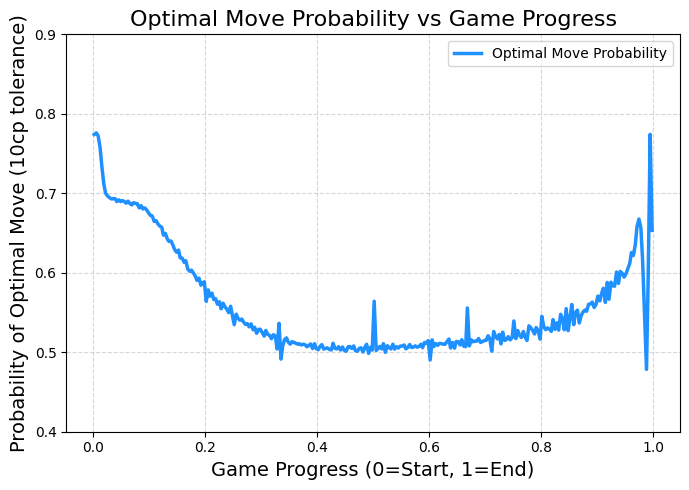

3184

In [ ]:
# 剔除强制走子（三参数也可以考虑是否删除强制走子）
musk = df_moves[(df_moves['Is_Forced'] != 1)] # & (df_moves['Is_check'] != 1) & (df_moves['Is_checkmate'] != 1)]

plt.figure(figsize=(7,5))
musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=300)
df_acc = musk.groupby('Progress_Bin')['Is_Optimal'].mean().reset_index()
df_acc['Progress'] = df_acc['Progress_Bin'].apply(lambda x: x.mid).astype(float)
plt.plot(df_acc['Progress'], df_acc['Is_Optimal'], color='dodgerblue', linewidth=2.5, label='Optimal Move Probability')
plt.title('Optimal Move Probability vs Game Progress', fontsize=16)
plt.xlabel('Game Progress (0=Start, 1=End)', fontsize=14)
plt.ylabel('Probability of Optimal Move (10cp tolerance)', fontsize=14)
plt.ylim(0.4, 0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

del musk
gc.collect()

这部分是纠结tolerance cp到底是10cp还是5cp

In [18]:
total_optimal_ratio = df_moves['Is_Optimal'].mean()
print(f"总体最优手比例 (Is_Optimal=1): {total_optimal_ratio:.2%}")

# 2. 统计 0 和 1 的具体数量
counts = df_moves['Is_Optimal'].value_counts()
print("\n具体数值分布:")
print(counts)

# 3. 按阶段查看（简单划分为 开局/中局/残局）
def get_stage(progress):
    if progress < 0.2: return 'Opening'
    if progress < 0.7: return 'Midgame'
    return 'Endgame'

df_moves['Stage'] = df_moves['Progress'].apply(get_stage)
stage_stats = df_moves.groupby('Stage')['Is_Optimal'].mean()

print("\n各阶段最优手比例:")
print(stage_stats)

总体最优手比例 (Is_Optimal=1): 55.94%

具体数值分布:
Is_Optimal
1    49736556
0    39175478
Name: count, dtype: int64

各阶段最优手比例:
Stage
Endgame    0.561332
Midgame    0.518784
Opening    0.661762
Name: Is_Optimal, dtype: float64


In [24]:
# 假设你有每一手的 Loss 数据列 'CP_Loss'
# 如果没有，根据 Score_Best - Score_Played 计算

thresholds = [20, 10, 5, 2, 0]
for t in thresholds:
    ratio = (df_moves['Δi'] <= t).mean()
    print(f"当阈值为 {t:2d} cp 时，最优手比例为: {ratio:.2%}")

当阈值为 20 cp 时，最优手比例为: 67.74%
当阈值为 10 cp 时，最优手比例为: 55.94%
当阈值为  5 cp 时，最优手比例为: 45.02%
当阈值为  2 cp 时，最优手比例为: 35.51%
当阈值为  0 cp 时，最优手比例为: 27.87%


In [29]:
pd.set_option('display.max_columns', None)  # 显示所有列
# df_moves[['uid', 'Move_Idx', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5', 'Δ', 'Δi', 'Is_Optimal']].head(60)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16160\4024666183.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_time = df_moves.groupby('Progress_Bin')['Move_Time'].mean().reset_index()


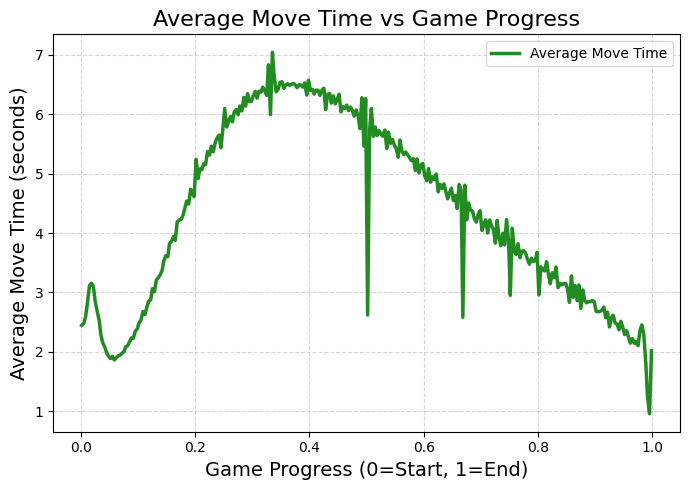

In [ ]:
plt.figure(figsize=(7, 5))
df_moves['Progress_Bin'] = pd.cut(df_moves['Progress'], bins=300)
df_time = df_moves.groupby('Progress_Bin')['Move_Time'].mean().reset_index()
df_time['Progress'] = df_time['Progress_Bin'].apply(lambda x: x.mid).astype(float)

plt.plot(df_time['Progress'], df_time['Move_Time'], color='forestgreen', linewidth=2.5, label='Average Move Time')
plt.title('Average Move Time vs Game Progress', fontsize=16)
plt.xlabel('Game Progress (0=Start, 1=End)', fontsize=14)
plt.ylabel('Average Move Time (seconds)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
del df_time
gc.collect()

0

## 四张图画到一个大图里面

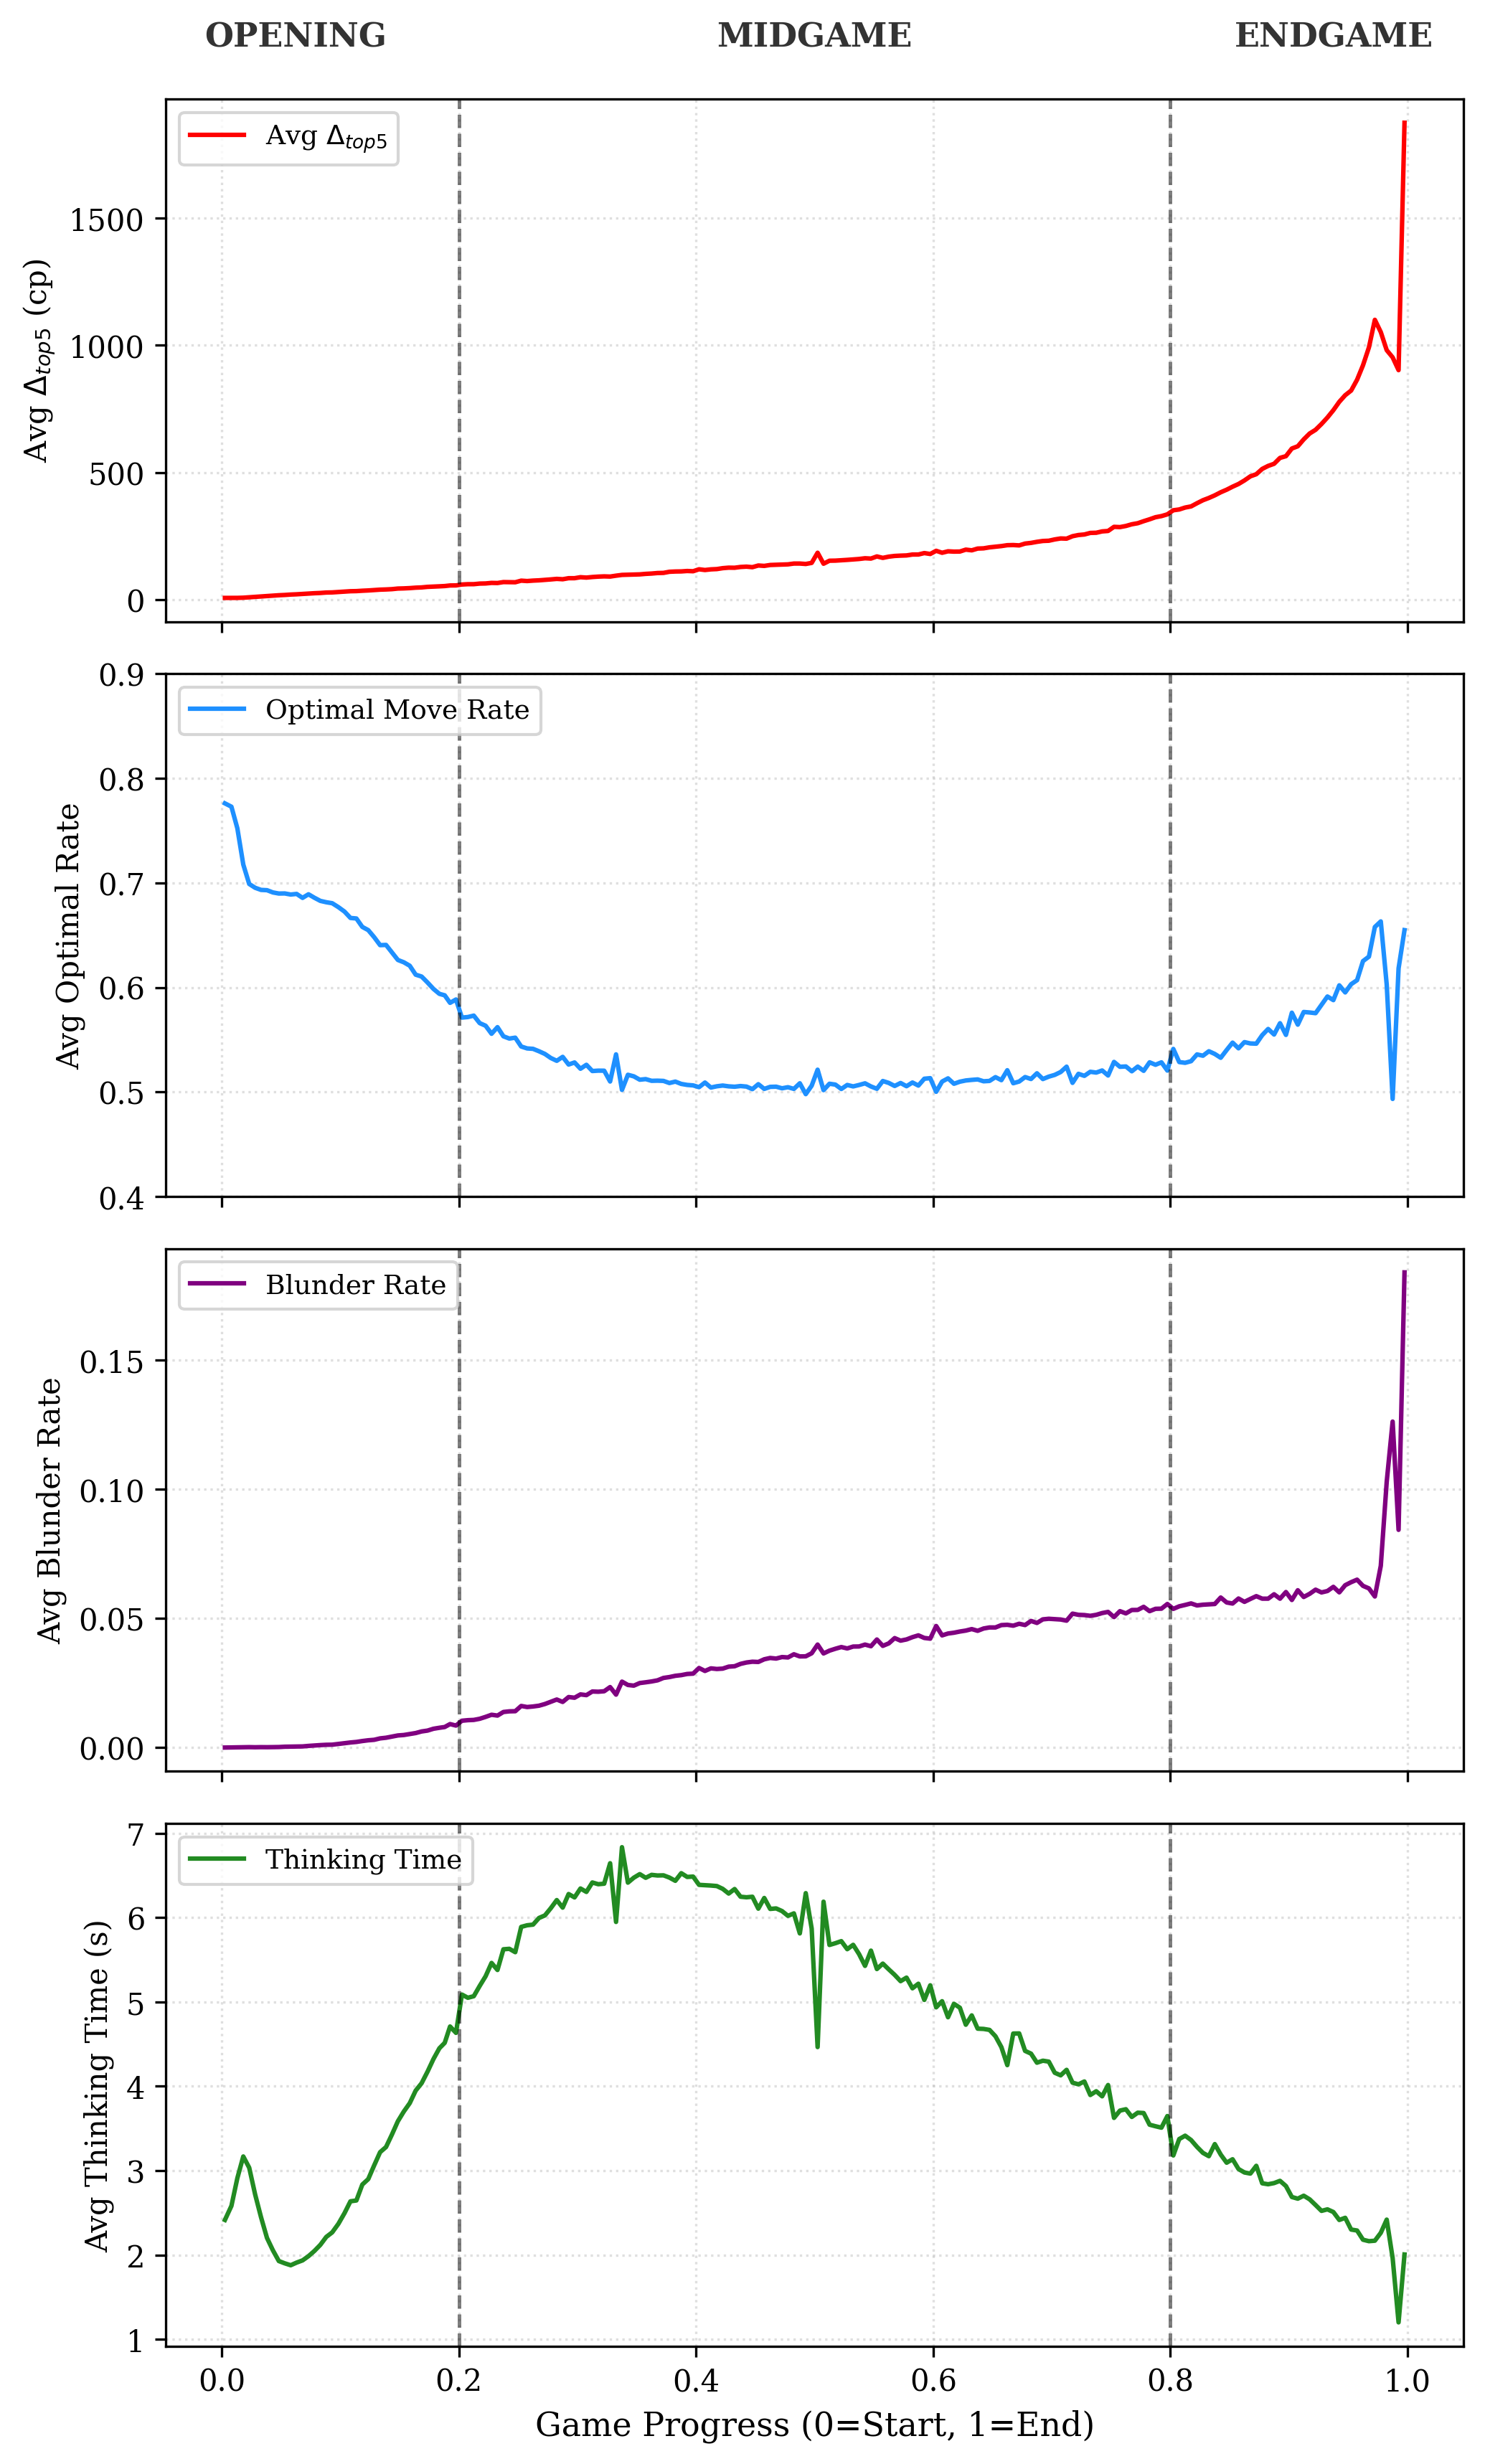

13468

In [42]:
split_1 = 0.2  # Opening -> Midgame
split_2 = 0.8  # Midgame -> Endgame
STAGE_FONT_SIZE = 11
STAGE_COLOR = '#333333'
BINS = 200
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(7, 12), sharex=True, dpi=300
)
# 全局字体为衬线体（适合论文）
plt.rcParams['font.family'] = 'serif'

# --- 1. Top Plot: Average Delta ---
df_moves['Progress_Bin'] = pd.cut(df_moves['Progress'], bins=BINS)
df_mean = df_moves.groupby('Progress_Bin', observed=False)['Δ'].mean().reset_index()
df_mean['Progress_mid'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

ax1.plot(df_mean['Progress_mid'], df_mean['Δ'], color='red', linewidth=1.5, label=r'Avg $\Delta_{top5}$')
ax1.set_ylabel(r'Avg $\Delta_{top5}$ (cp)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9)

# 在第一个子图上方标注阶段文字
ax1.text(split_1/2, 1.1, 'OPENING', transform=ax1.transAxes, 
         ha='center', fontsize=STAGE_FONT_SIZE, fontweight='bold', color=STAGE_COLOR)
ax1.text((split_1+split_2)/2, 1.1, 'MIDGAME', transform=ax1.transAxes, 
         ha='center', fontsize=STAGE_FONT_SIZE, fontweight='bold', color=STAGE_COLOR)
ax1.text((split_2+1)/2, 1.1, 'ENDGAME', transform=ax1.transAxes, 
         ha='center', fontsize=STAGE_FONT_SIZE, fontweight='bold', color=STAGE_COLOR)

# --- 2. Second Plot: Optimal Move Rate (Filtered) ---
# 剔除强制走子，因为强制走子通常不涉及“寻找最优”的决策难度
musk = df_moves[df_moves['Is_Forced'] != 1].copy()
musk['Progress_Bin'] = pd.cut(musk['Progress'], bins=BINS)
df_acc = musk.groupby('Progress_Bin', observed=False)['Is_Optimal'].mean().reset_index()
df_acc['Progress_mid'] = df_acc['Progress_Bin'].apply(lambda x: x.mid).astype(float)

ax2.plot(df_acc['Progress_mid'], df_acc['Is_Optimal'], color='dodgerblue', linewidth=1.5, label='Optimal Move Rate')
ax2.set_ylabel('Avg Optimal Rate', fontsize=10)
ax2.set_ylim(0.4, 0.9) 
ax2.legend(loc='upper left', fontsize=9)

# --- 3. Third Plot: Blunder Rate (Filtered) ---
# 剔除强制走子：强制走子通常不会是 Blunder（除非只有一步送死），剔除后更显人类失误特征
df_blun = musk.groupby('Progress_Bin', observed=False)['Is_Blunder'].mean().reset_index()
df_blun['Progress_mid'] = df_blun['Progress_Bin'].apply(lambda x: x.mid).astype(float)

# 使用紫色或深橙色来代表“失误”
ax3.plot(df_blun['Progress_mid'], df_blun['Is_Blunder'], color='purple', linewidth=1.5, label='Blunder Rate')
ax3.set_ylabel('Avg Blunder Rate', fontsize=10)
# 根据数据调整 ylim，通常 blunder 概率在 0.0 到 0.2 左右
# ax3.set_ylim(0, 0.15) 
ax3.legend(loc='upper left', fontsize=9)

# --- 4. Bottom Plot: Average Thinking Time ---
df_time = df_moves.groupby('Progress_Bin', observed=False)['Move_Time'].mean().reset_index()
df_time['Progress_mid'] = df_time['Progress_Bin'].apply(lambda x: x.mid).astype(float)

ax4.plot(df_time['Progress_mid'], df_time['Move_Time'], color='forestgreen', linewidth=1.5, label='Thinking Time')
ax4.set_ylabel('Avg Thinking Time (s)', fontsize=10)
ax4.set_xlabel('Game Progress (0=Start, 1=End)', fontsize=11)
ax4.legend(loc='upper left', fontsize=9)

# 分界线、网格、边框优化
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(x=split_1, color='black', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.axvline(x=split_2, color='black', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

del musk, df_mean, df_acc, df_blun, df_time
gc.collect()